In [17]:
import uproot
import numpy as np
import pandas as pd
import os

# Carpeta con tus archivos ROOT
input_folder = "NeutronData"   # ajusta la ruta
output_csv = "thermalization_summary.csv"

results = []

# --- Bucle por cada archivo .root ---
for file_name in sorted(os.listdir(input_folder)):
    if not file_name.endswith(".root"):
        continue

    path = os.path.join(input_folder, file_name)
    print(f"Procesando {file_name}...")

    # Extraer los valores de geometría desde el nombre
    # Ejemplo: NeutronData_1.0x1.0x1.0.root  →  X=1.0, Y=1.0, Z=1.0
    base = file_name.replace("NeutronData_", "").replace(".root", "")
    try:
        X, Y, Z = [float(x) for x in base.split("x")]
    except:
        X, Y, Z = np.nan, np.nan, np.nan

    # Abrir el archivo ROOT
    with uproot.open(path) as file:
        # Intenta detectar el árbol y la rama de energía
        tree = None
        for key in file.keys():
            if "NeutronData" in key or "tree" in key:
                tree = file[key]
                break
        if tree is None:
            tree = list(file.values())[0]  # toma el primero si no detecta

        # Detectar la rama de energía
        branch_name = None
        for name in tree.keys():
            if "energy" in name.lower() or "kinetic" in name.lower():
                branch_name = name
                break
        if branch_name is None:
            branch_name = tree.keys()[0]  # usa la primera si no detecta

        # Leer la energía en eV
        energy = tree[branch_name].array(library="np")

        # Si está en MeV, conviértela
        if np.mean(energy) < 1e4:  # umbral arbitrario
            energy = energy * 1e6

        # --- Cálculos ---
        total_detected = len(energy)
        thermal = np.sum(energy < 0.025)         # E < 0.025 eV
        epithermal = np.sum((energy >= 0.025) & (energy < 0.5))
        fast = np.sum(energy >= 0.5)

        results.append({
            "File_name": file_name,
            "Widht_(cm)": X,
            "High_(cm)": Y,
            "Thickness(cm)": Z,
            "Detected": total_detected,
            "Thermics": int(thermal),
            "EpiThermics": int(epithermal),
            "Fast": int(fast),
        })

# --- Guardar a CSV ---
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"\n✅ Resultados guardados en {output_csv}")
print(df.head())


Procesando NeutronData_1.0x1.0x1.0.root...
Procesando NeutronData_1.0x1.0x10.0.root...
Procesando NeutronData_1.0x1.0x11.0.root...
Procesando NeutronData_1.0x1.0x12.0.root...
Procesando NeutronData_1.0x1.0x13.0.root...
Procesando NeutronData_1.0x1.0x14.0.root...
Procesando NeutronData_1.0x1.0x15.0.root...
Procesando NeutronData_1.0x1.0x16.0.root...
Procesando NeutronData_1.0x1.0x17.0.root...
Procesando NeutronData_1.0x1.0x18.0.root...
Procesando NeutronData_1.0x1.0x19.0.root...
Procesando NeutronData_1.0x1.0x2.0.root...
Procesando NeutronData_1.0x1.0x20.0.root...
Procesando NeutronData_1.0x1.0x21.0.root...
Procesando NeutronData_1.0x1.0x22.0.root...
Procesando NeutronData_1.0x1.0x23.0.root...
Procesando NeutronData_1.0x1.0x24.0.root...
Procesando NeutronData_1.0x1.0x25.0.root...
Procesando NeutronData_1.0x1.0x26.0.root...
Procesando NeutronData_1.0x1.0x27.0.root...
Procesando NeutronData_1.0x1.0x28.0.root...
Procesando NeutronData_1.0x1.0x29.0.root...
Procesando NeutronData_1.0x1.0x3.0

In [4]:
import os
import re

# Carpeta donde están tus archivos .root
folder = "NeutronData"

# Regex para nombres tipo: NeutronData_1.0x2.0x3.0.root
pattern = re.compile(r"NeutronData_(\d+\.?\d*)x(\d+\.?\d*)x(\d+\.?\d*)\.root")

# --- 1. Leer archivos existentes ---
existing = set()

for fname in os.listdir(folder):
    match = pattern.match(fname)
    if match:
        x, y, z = match.groups()
        existing.add((int(float(x)), int(float(y)), int(float(z))))

print(f"Archivos encontrados: {len(existing)}")

# --- 2. Generar TODAS las geometrías posibles 1–30 cm ---
expected = {(X, Y, Z) for X in range(1, 31)
                        for Y in range(1, 31)
                        for Z in range(1, 31)}

print(f"Geometrías esperadas: {len(expected)}")

# --- 3. Detectar faltantes ---
missing = sorted(expected - existing)

print(f"\nFALTAN {len(missing)} GEOMETRÍAS\n")

# Mostrar algunas
if missing:
    print("Primeras 30 faltantes (X, Y, Z):")
    for m in missing[:30]:
        print(m)

    print("\nNombres de archivos faltantes:")
    for X, Y, Z in missing[:30]:
        print(f"NeutronData_{X}.0x{Y}.0x{Z}.0.root")
else:
    print("✔️ No falta ninguna simulación.")


Archivos encontrados: 27000
Geometrías esperadas: 27000

FALTAN 0 GEOMETRÍAS

✔️ No falta ninguna simulación.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# -------------------------
# Global Scientific Style
# -------------------------
mpl.rcParams["figure.dpi"] = 400
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.labelsize"] = 13
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["xtick.labelsize"] = 11
mpl.rcParams["ytick.labelsize"] = 11
mpl.rcParams["axes.grid"] = True

# -------------------------
# Load CSV
# -------------------------
csv_file = "thermalization_summary.csv"
total_neutrons = 10000

df = pd.read_csv(csv_file)

for col in ["Widht_(cm)", "High_(cm)", "Thickness(cm)", "Thermics"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Compute thermalization efficiency
df["Thermal_Efficiency"] = df["Thermics"] / total_neutrons * 100

# Identify optimum geometry
best = df.loc[df["Thermal_Efficiency"].idxmax()]

print("\n=== OPTIMAL GEOMETRY ===")
print(best)
print("=========================\n")


# -------------------------
# 3D Scatter Plots
# -------------------------
from mpl_toolkits.mplot3d import Axes3D

def plot_3d(x, y, xlabel, ylabel, filename):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection="3d")
    sc = ax.scatter(df[x], df[y], df["Thermal_Efficiency"],
                    c=df["Thermal_Efficiency"], cmap="viridis", s=35)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_zlabel("Thermalization Efficiency (%)")
    plt.title(f"Efficiency as a Function of {xlabel} and {ylabel}")
    fig.colorbar(sc, label="Efficiency (%)")
    plt.tight_layout()
    plt.savefig(filename, dpi=400)
    plt.close()

plot_3d("Widht_(cm)", "High_(cm)", "Width (cm)", "Height (cm)", "eff_3d_width_height.png")
plot_3d("High_(cm)", "Thickness(cm)", "Height (cm)", "Thickness (cm)", "eff_3d_height_thickness.png")
plot_3d("Widht_(cm)", "Thickness(cm)", "Width (cm)", "Thickness (cm)", "eff_3d_width_thickness.png")

# -------------------------
# 2D Heatmaps
# -------------------------


print("All scientific plots generated successfully.")



=== OPTIMAL GEOMETRY ===
File_name             NeutronData_24.0x30.0x9.0.root
Widht_(cm)                                      24.0
High_(cm)                                       30.0
Thickness(cm)                                    9.0
Detected                                        1921
Thermics                                          26
EpiThermics                                       22
Fast                                            1873
Thermal_Efficiency                              0.26
Name: 15119, dtype: object

All scientific plots generated successfully.


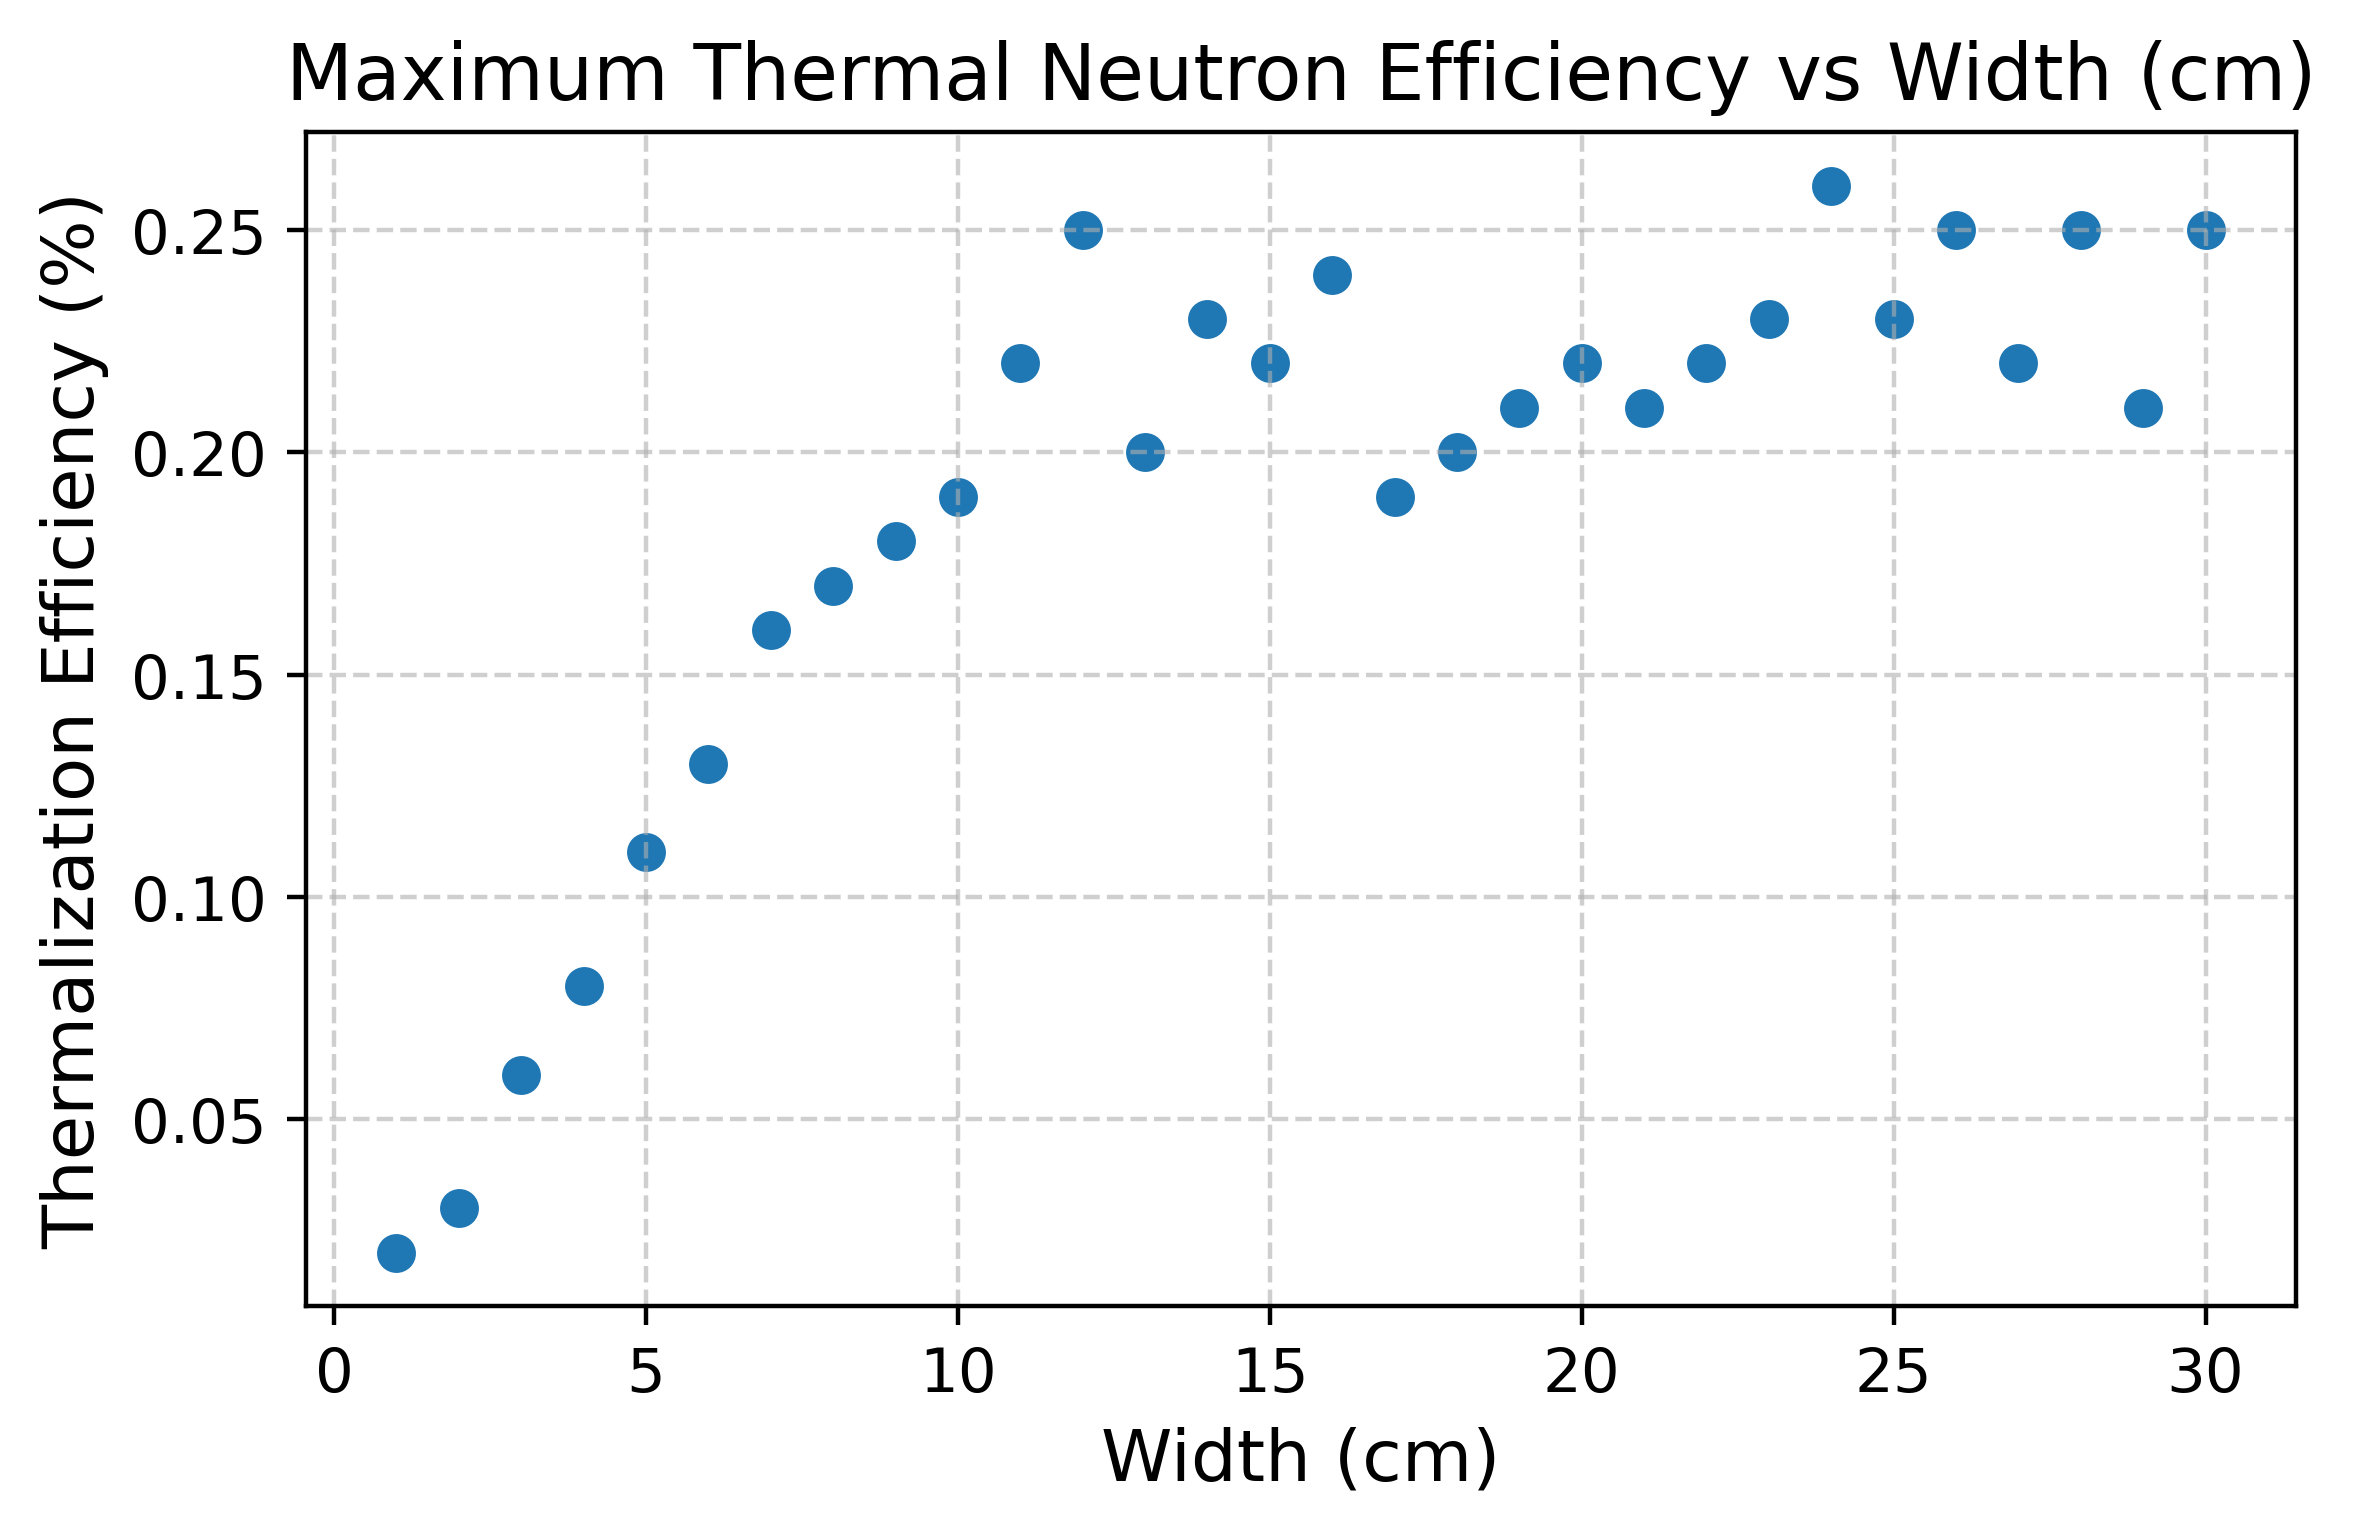

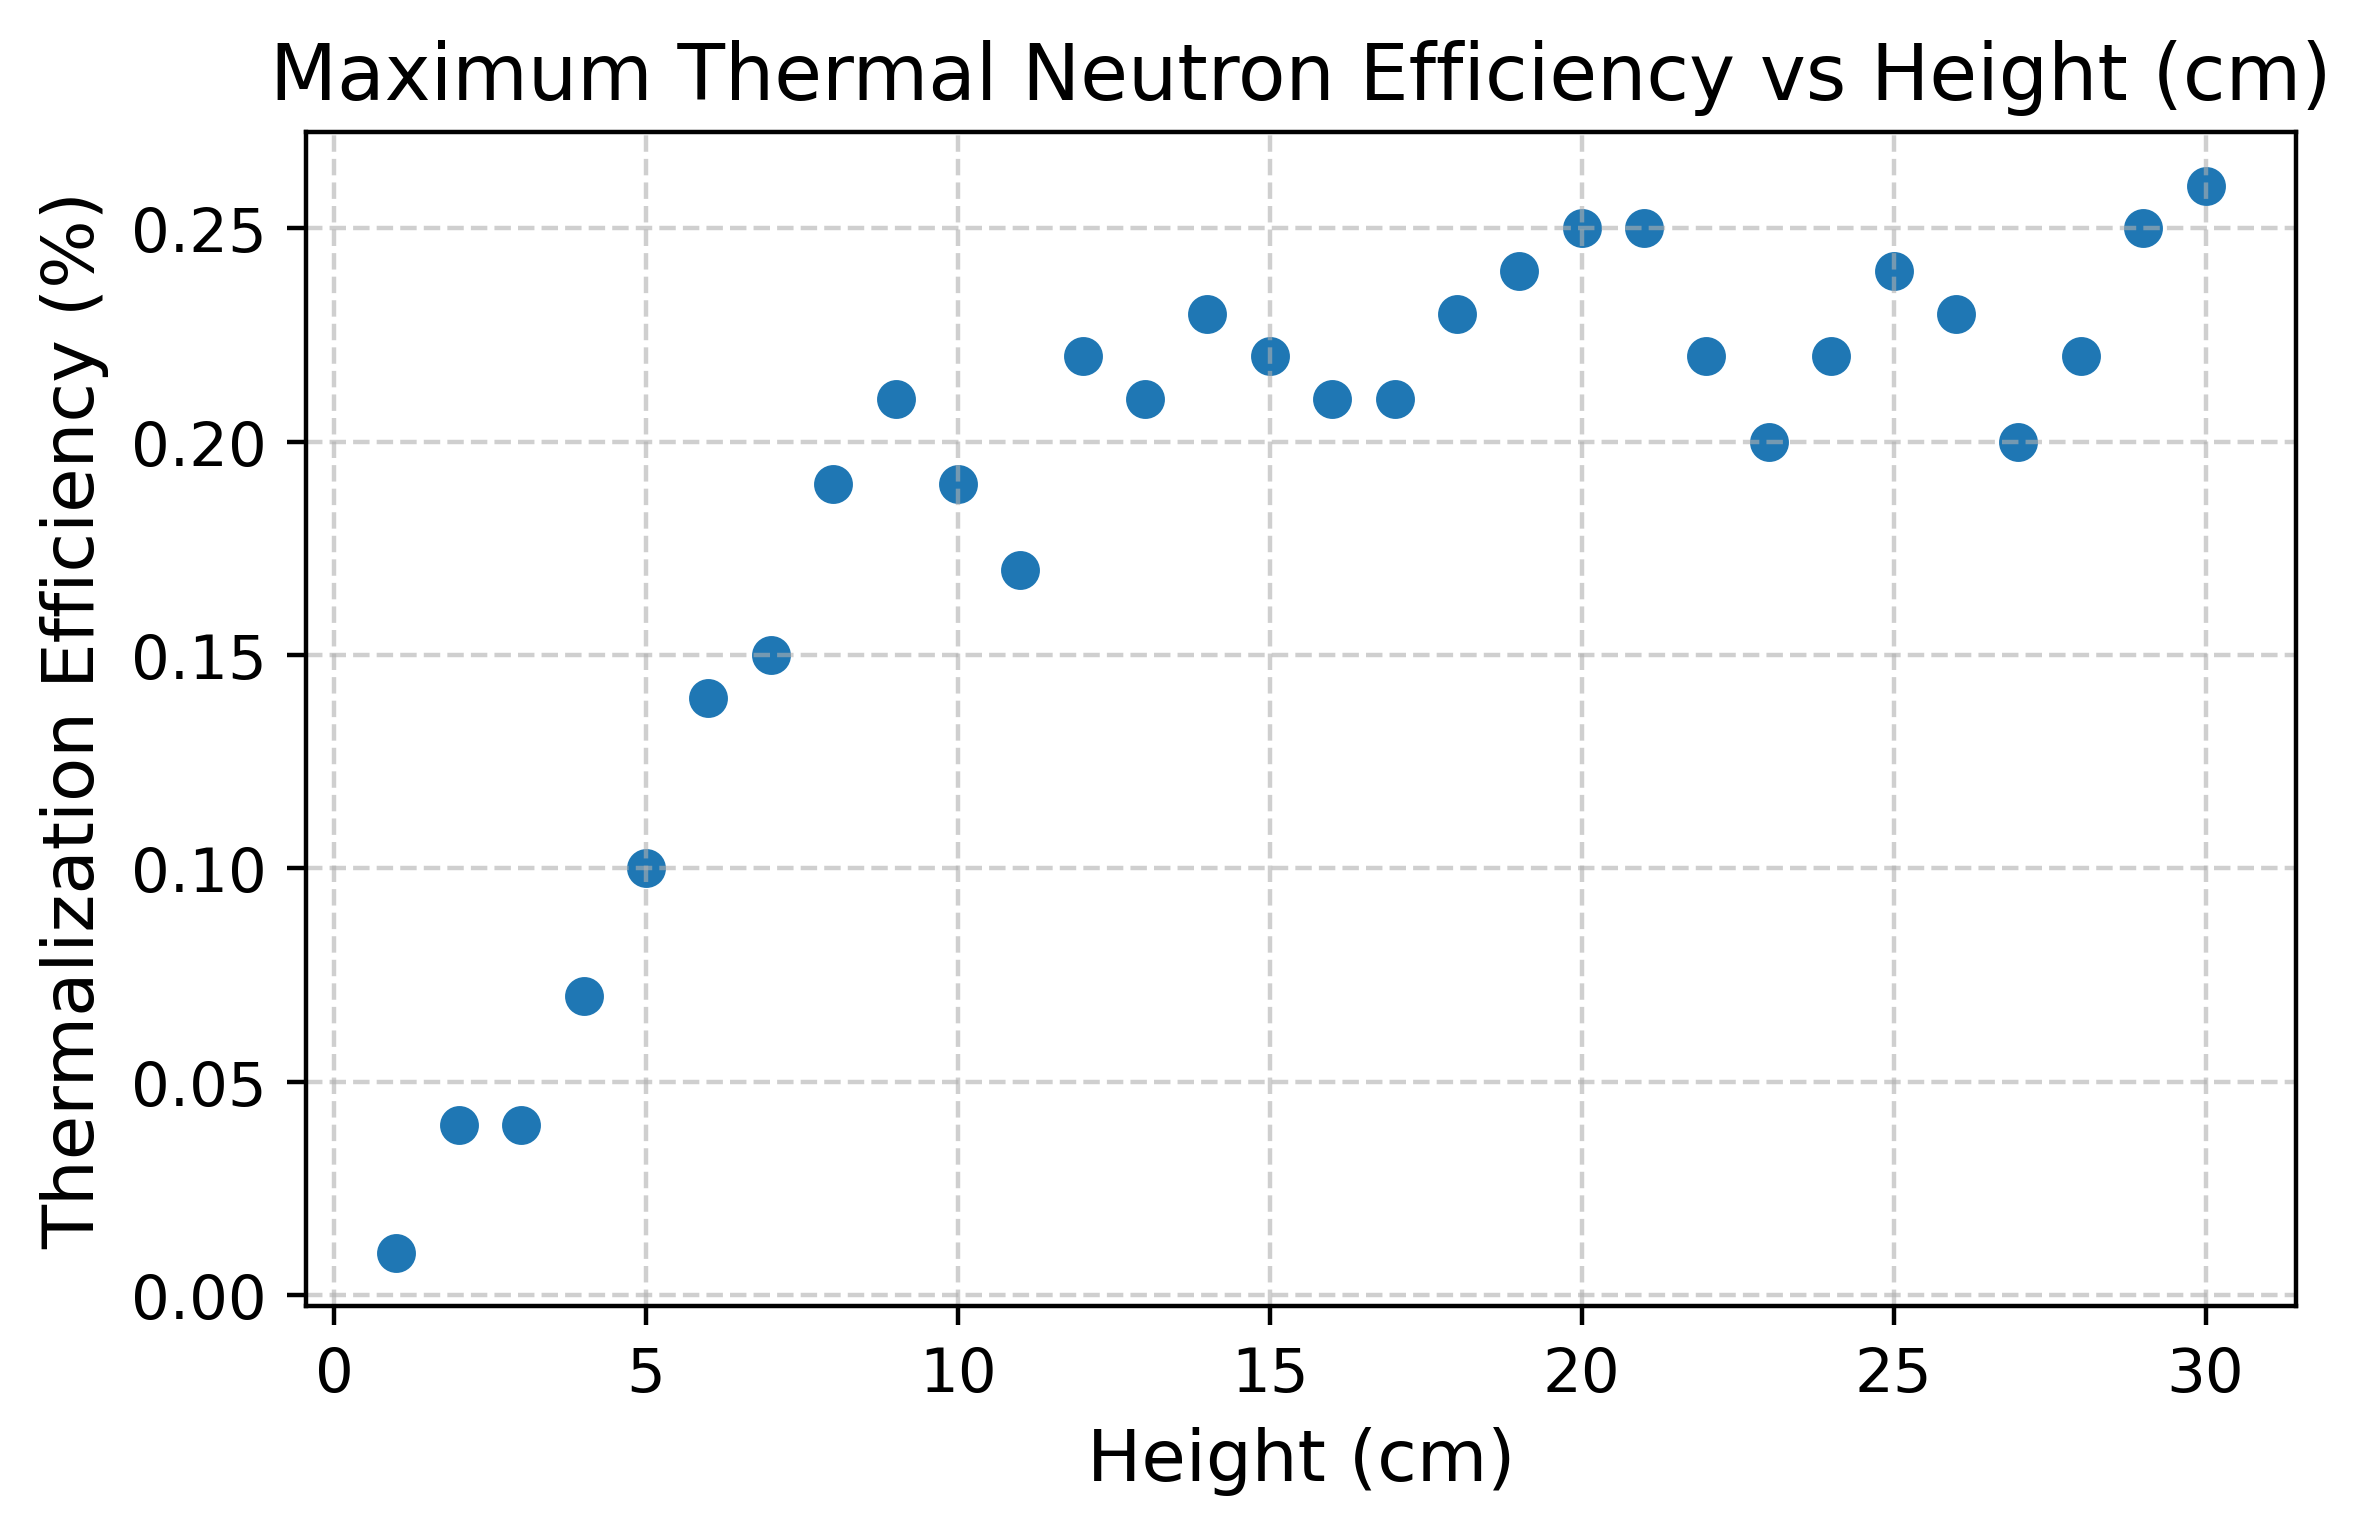

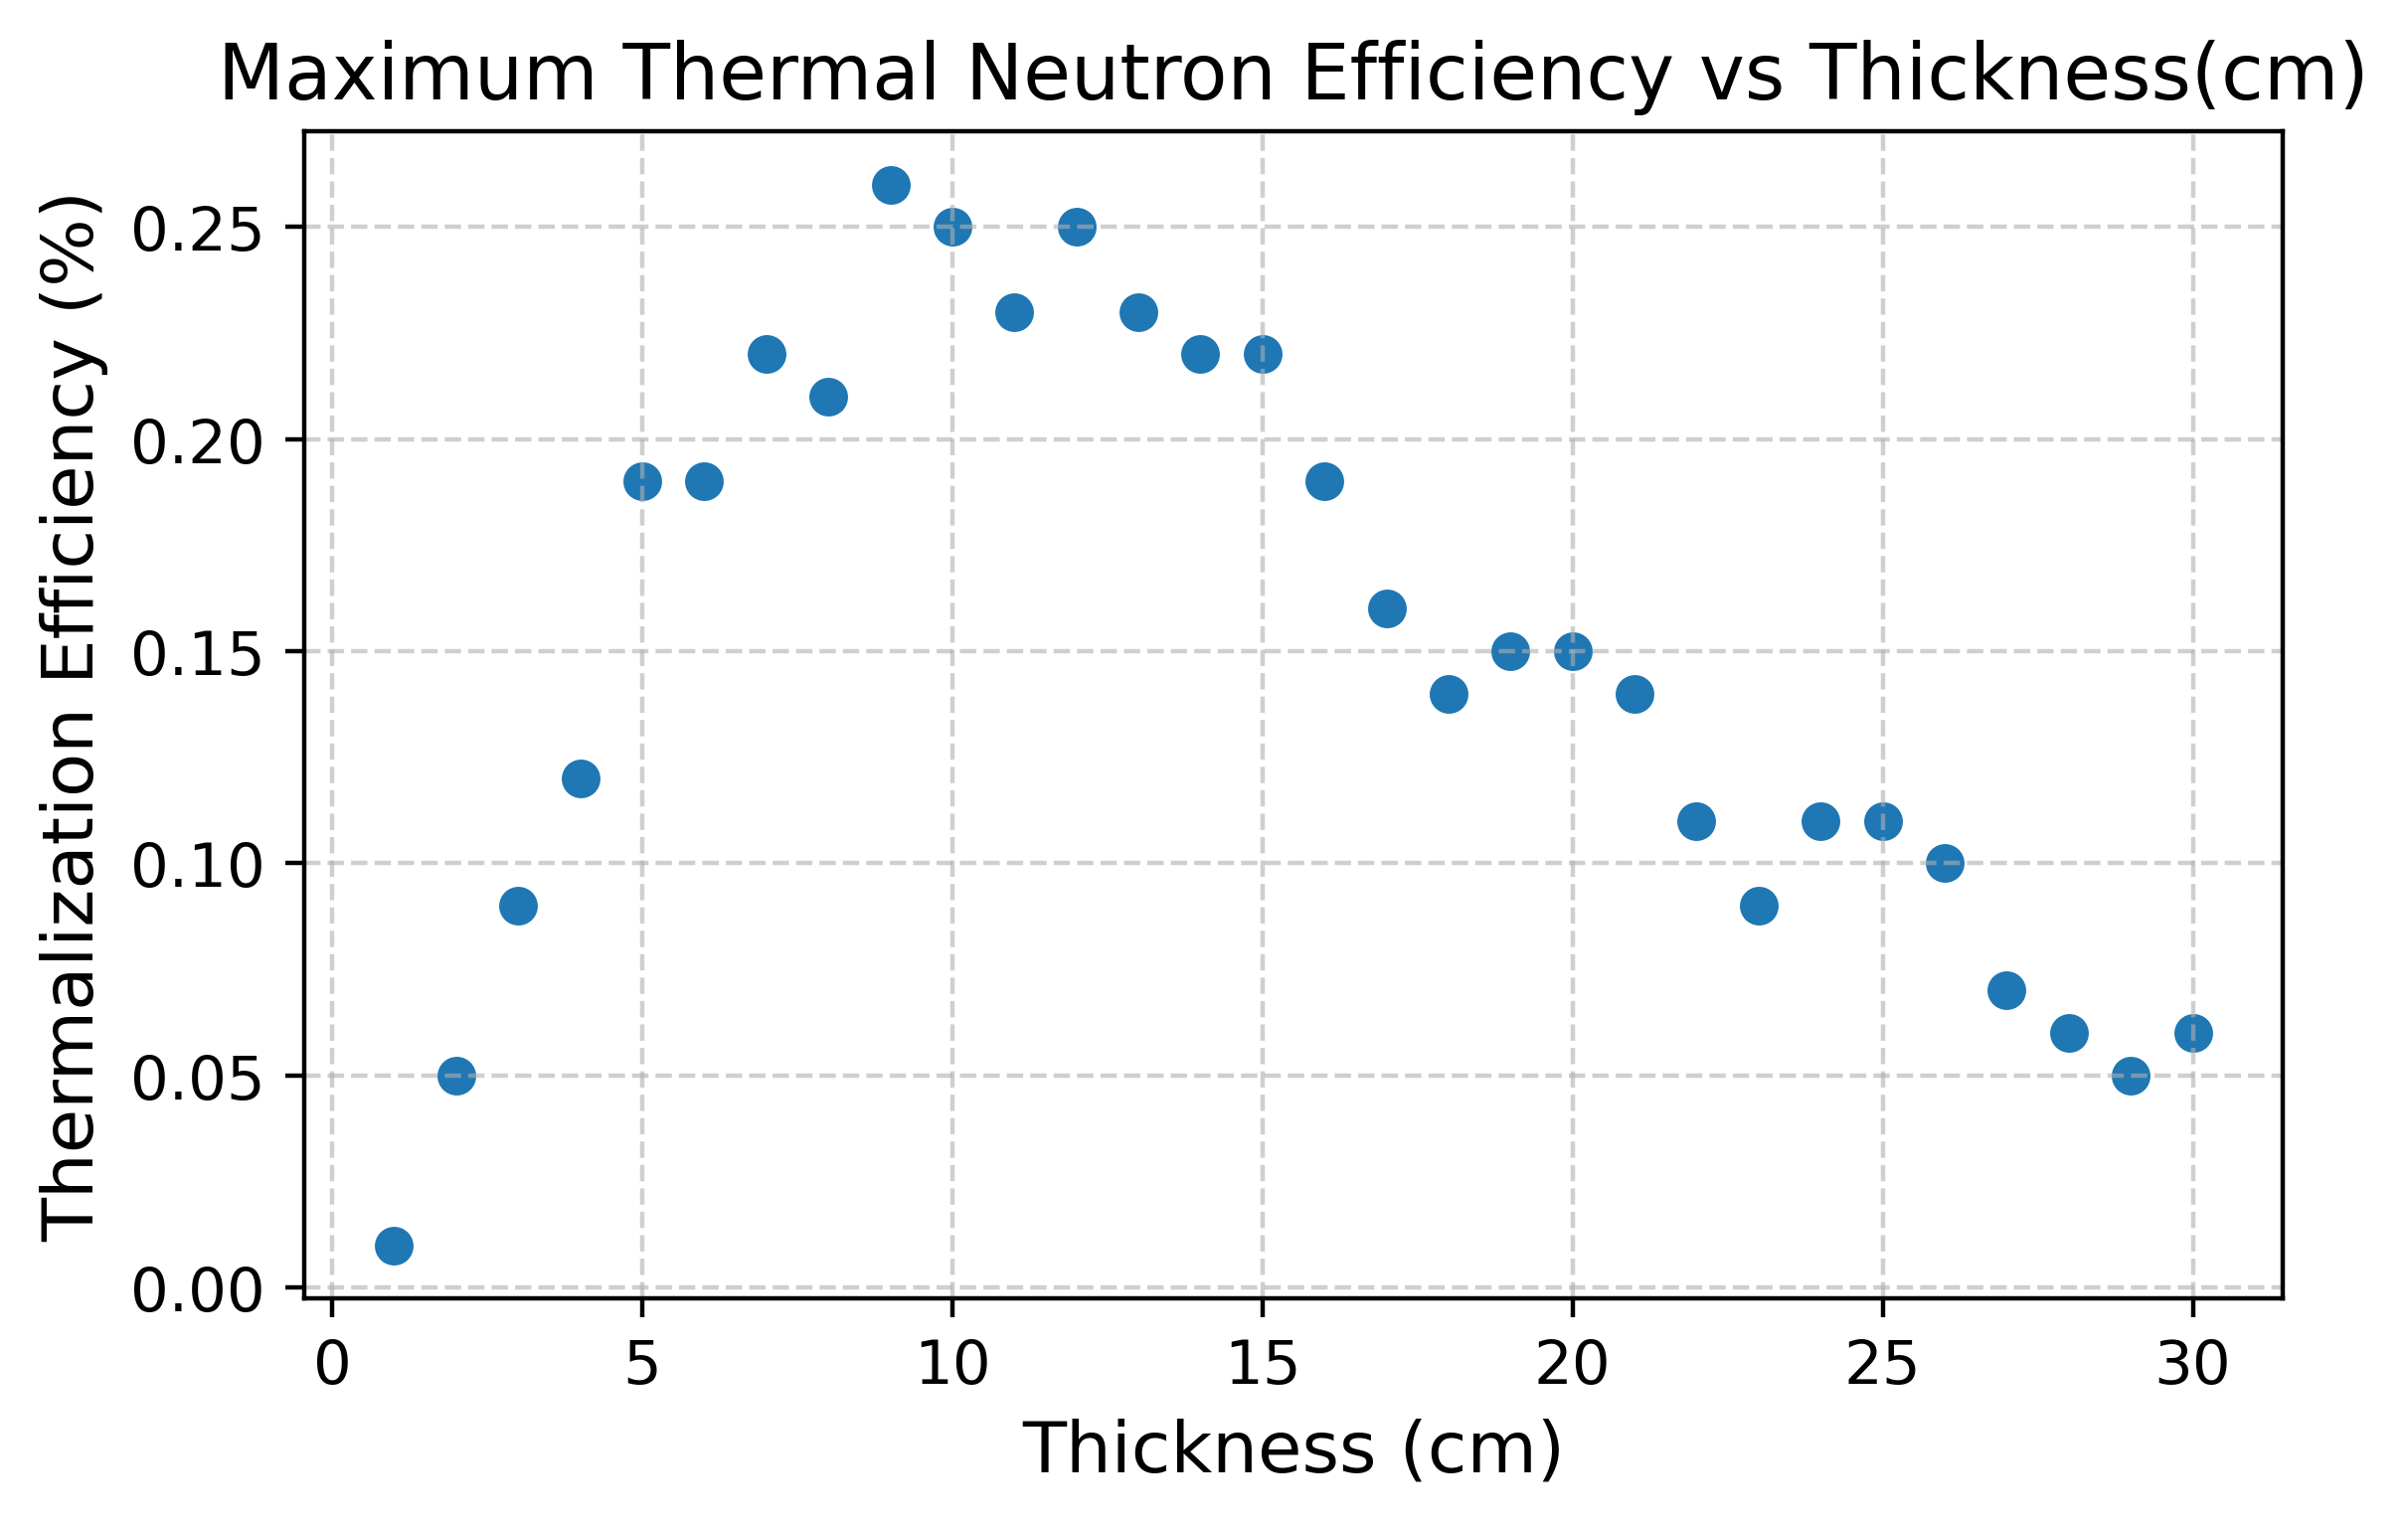

In [16]:
# --- Max efficiency per Width ---
max_width = df.groupby("Widht_(cm)")["Thermal_Efficiency"].max().reset_index()

plt.figure(figsize=(6,4))
plt.scatter(max_width["Widht_(cm)"], max_width["Thermal_Efficiency"])

plt.xlabel("Width (cm)")
plt.ylabel("Thermalization Efficiency (%)")
plt.title("Maximum Thermal Neutron Efficiency vs Width (cm)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("eff_max_vs_width.png", dpi=400)
plt.show()

max_height = df.groupby("High_(cm)")["Thermal_Efficiency"].max().reset_index()

plt.figure(figsize=(6,4))
plt.scatter(max_height["High_(cm)"], max_height["Thermal_Efficiency"])

plt.xlabel("Height (cm)")
plt.ylabel("Thermalization Efficiency (%)")
plt.title("Maximum Thermal Neutron Efficiency vs Height (cm)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("eff_max_vs_height.png", dpi=400)
plt.show()

max_thickness = df.groupby("Thickness(cm)")["Thermal_Efficiency"].max().reset_index()

plt.figure(figsize=(6,4))
plt.scatter(max_thickness["Thickness(cm)"], max_thickness["Thermal_Efficiency"])

plt.xlabel("Thickness (cm)")
plt.ylabel("Thermalization Efficiency (%)")
plt.title("Maximum Thermal Neutron Efficiency vs Thickness(cm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("eff_max_vs_thickness.png", dpi=400)
plt.show()

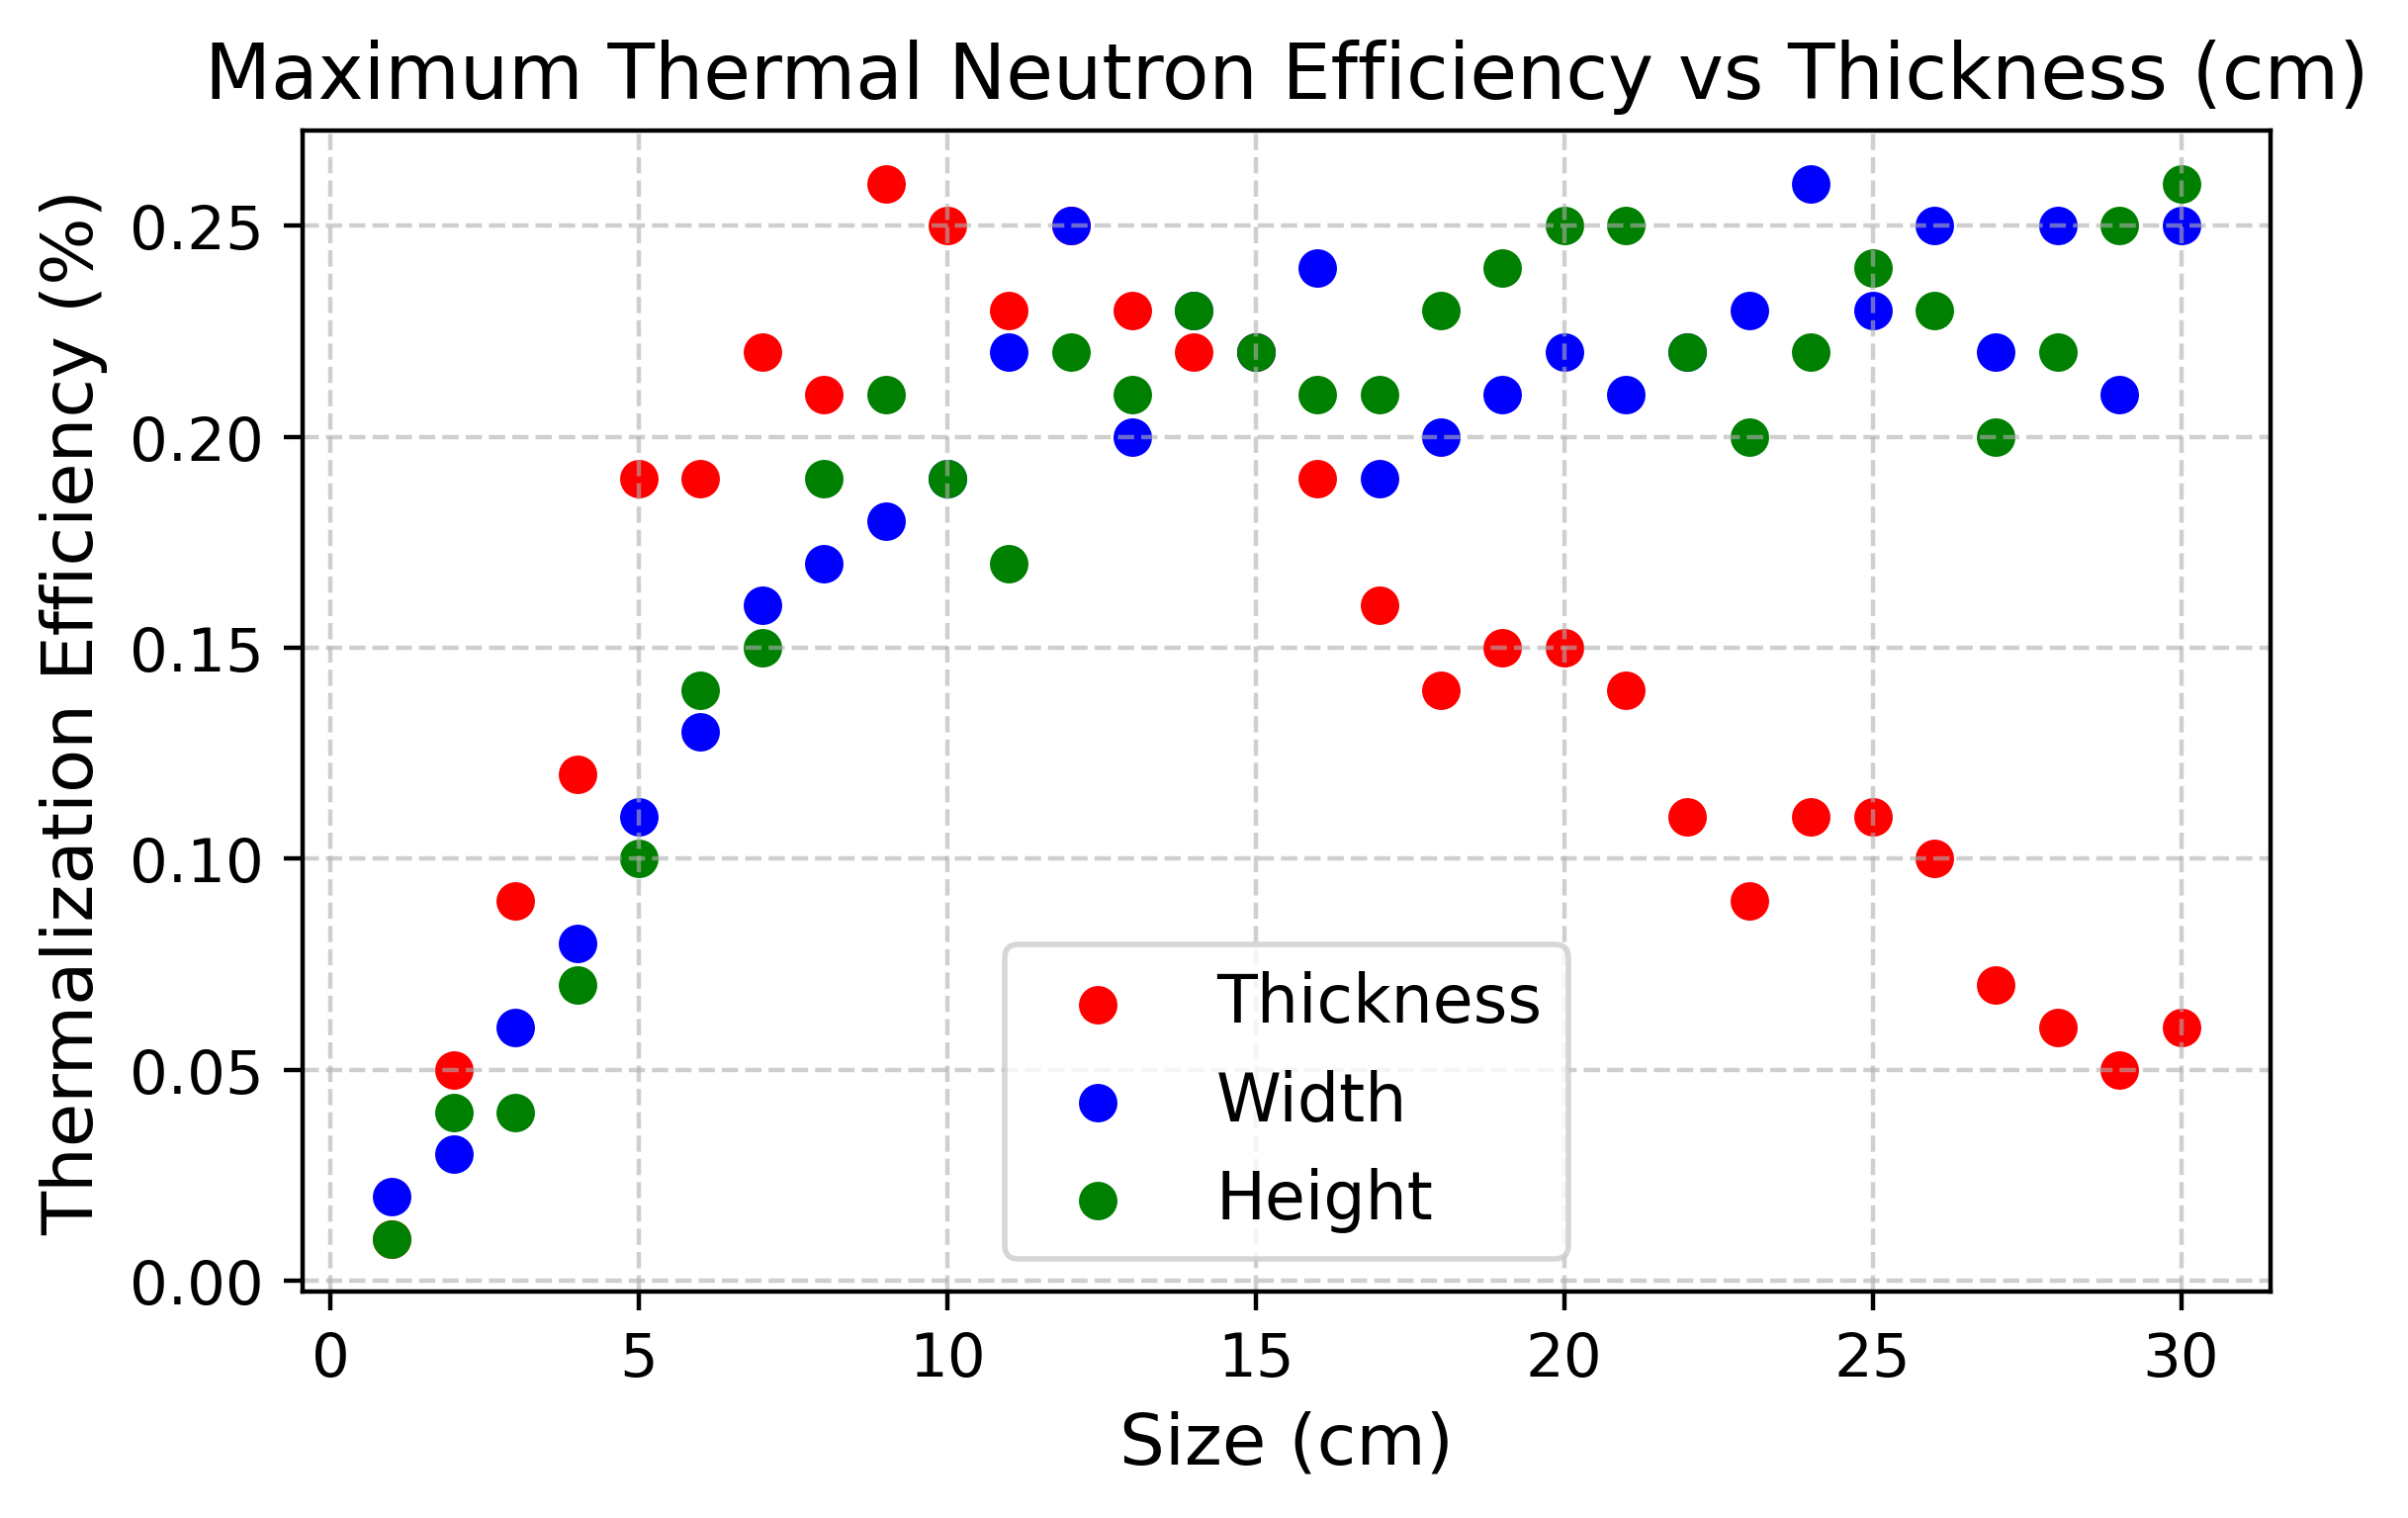

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

plt.figure(figsize=(6,4))
plt.scatter(max_thickness["Thickness(cm)"], max_thickness["Thermal_Efficiency"],c="r",label="Thickness")
plt.scatter(max_width["Widht_(cm)"], max_width["Thermal_Efficiency"],c="b",label="Width")
plt.scatter(max_height["High_(cm)"], max_height["Thermal_Efficiency"],c="g",label="Height")

plt.xlabel("Size (cm)")
plt.ylabel("Thermalization Efficiency (%)")
plt.legend()
plt.title("Maximum Thermal Neutron Efficiency vs Thickness (cm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("eff_max_vs_size.png", dpi=400)
plt.show()

In [22]:
import matplotlib.pyplot as plt

# ==========================================================
# 1) MAX EFFICIENCY MAP: HEIGHT vs THICKNESS
# ==========================================================

df_HT = df.groupby(["High_(cm)", "Thickness(cm)"])["Thermal_Efficiency"].max().reset_index()
pivot_HT = df_HT.pivot(index="High_(cm)", columns="Thickness(cm)", values="Thermal_Efficiency")

plt.figure(figsize=(8,6))
plt.imshow(pivot_HT, origin="lower", cmap="magma", aspect="auto")
cbar = plt.colorbar()
cbar.set_label("Maximum Thermalization Efficiency (%)")

plt.xlabel("Thickness (cm)")
plt.ylabel("Height (cm)")
plt.title("Maximum Thermal Efficiency Map: Height vs Thickness")
plt.grid(True, color="white", alpha=0.2)
plt.tight_layout()
plt.savefig("max_eff_map_height_vs_thickness.png", dpi=400)
plt.close()


# ==========================================================
# 2) MAX EFFICIENCY MAP: WIDTH vs HEIGHT
# ==========================================================

df_WH = df.groupby(["Widht_(cm)", "High_(cm)"])["Thermal_Efficiency"].max().reset_index()
pivot_WH = df_WH.pivot(index="High_(cm)", columns="Widht_(cm)", values="Thermal_Efficiency")

plt.figure(figsize=(8,6))
plt.imshow(pivot_WH, origin="lower", cmap="magma", aspect="auto")
cbar = plt.colorbar()
cbar.set_label("Maximum Thermalization Efficiency (%)")

plt.xlabel("Width (cm)")
plt.ylabel("Height (cm)")
plt.title("Maximum Thermal Efficiency Map: Width vs Height")
plt.grid(True, color="white", alpha=0.2)
plt.tight_layout()
plt.savefig("max_eff_map_width_vs_height.png", dpi=400)
plt.close()


# ==========================================================
# 3) MAX EFFICIENCY MAP: WIDTH vs THICKNESS
# ==========================================================

df_WT = df.groupby(["Widht_(cm)", "Thickness(cm)"])["Thermal_Efficiency"].max().reset_index()
pivot_WT = df_WT.pivot(index="Widht_(cm)", columns="Thickness(cm)", values="Thermal_Efficiency")

plt.figure(figsize=(8,6))
plt.imshow(pivot_WT, origin="lower", cmap="magma", aspect="auto")
cbar = plt.colorbar()
cbar.set_label("Maximum Thermalization Efficiency (%)")

plt.xlabel("Thickness (cm)")
plt.ylabel("Width (cm)")
plt.title("Maximum Thermal Efficiency Map: Width vs Thickness")
plt.grid(True, color="white", alpha=0.2)
plt.tight_layout()
plt.savefig("max_eff_map_width_vs_thickness.png", dpi=400)
plt.close()



In [23]:
import os
import re
from collections import defaultdict

# Carpeta donde están tus archivos .root
folder = "NeutronData"

# Regex para nombres tipo: NeutronData_1.0x2.0x3.0.root
pattern = re.compile(r"NeutronData_(\d+\.?\d*)x(\d+\.?\d*)x(\d+\.?\d*)\.root")

# Diccionario para guardar todas las apariciones
# key = (X, Y, Z), value = lista de nombres de archivo
all_files = defaultdict(list)

# --- 1. Leer archivos existentes y registrar duplicados ---
for fname in os.listdir(folder):
    match = pattern.match(fname)
    if match:
        x, y, z = match.groups()
        key = (int(float(x)), int(float(y)), int(float(z)))
        all_files[key].append(fname)

# --- 2. Detectar duplicados ---
duplicates = {key: files for key, files in all_files.items() if len(files) > 1}

print(f"\n=== RESULTADO DE ARCHIVOS REPETIDOS ===")
print(f"Total geometrías únicas encontradas: {len(all_files)}")
print(f"Geometrías con archivos repetidos: {len(duplicates)}\n")

if duplicates:
    print("⚠️ Geometrías repetidas detectadas:\n")
    for (X, Y, Z), files in duplicates.items():
        print(f"Geometría ({X} cm, {Y} cm, {Z} cm) → {len(files)} archivos:")
        for f in files:
            print(f"   - {f}")
        print()
else:
    print("✔️ No se encontraron archivos repetidos.")



=== RESULTADO DE ARCHIVOS REPETIDOS ===
Total geometrías únicas encontradas: 27000
Geometrías con archivos repetidos: 0

✔️ No se encontraron archivos repetidos.
